# Importing libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Loading dataset

In [3]:
df = pd.read_csv('data/Titanic-Dataset.csv')

# Data understading

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [5]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Survivals

In [6]:
df['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [8]:
df['Survived'].value_counts(normalize=True)

Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

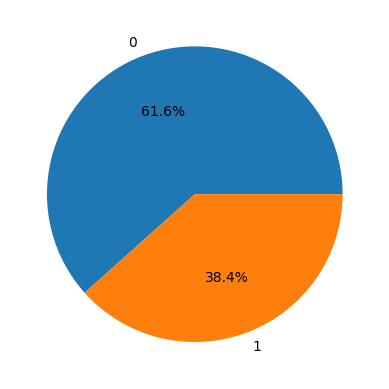

<BarContainer object of 2 artists>

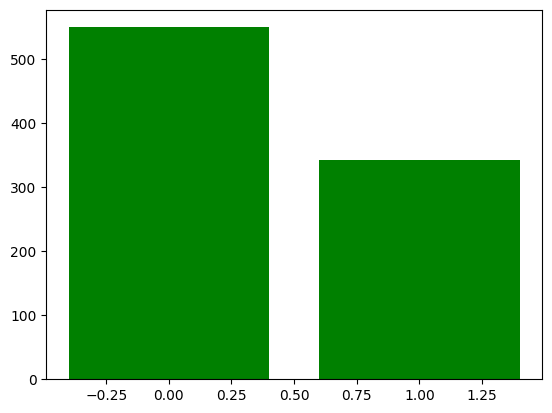

In [9]:
survived = df['Survived'].value_counts()

plt.pie(survived, labels= survived.index, autopct='%1.1f%%')
plt.show()

plt.bar( survived.index, survived, color="green")

## Pclass

In [10]:
df['Pclass'].unique()

array([3, 1, 2])

In [13]:


print("Fare values for each ticket class")

for pc in sorted(df['Pclass'].unique(), reverse=True):
    df_pc = df[df['Pclass'] == pc]['Fare']
    mean = df_pc.mean()
    min = df_pc.min()
    max = df_pc.max()
    range = max - min

    print(f"Mean for {pc} class is {mean}, MIN: {min}, MAX: {max}, RANGE: {range} ")


Fare values for each ticket class
Mean for 3 class is 13.675550101832993, MIN: 0.0, MAX: 69.55, RANGE: 69.55 
Mean for 2 class is 20.662183152173913, MIN: 0.0, MAX: 73.5, RANGE: 73.5 
Mean for 1 class is 84.1546875, MIN: 0.0, MAX: 512.3292, RANGE: 512.3292 


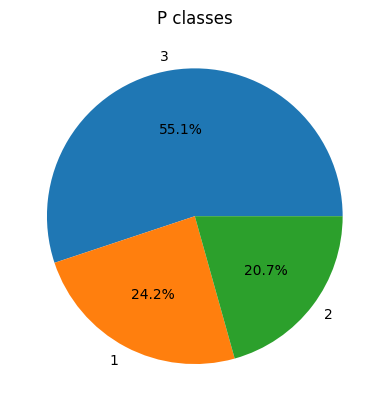

In [16]:
pclass = df['Pclass'].value_counts()

plt.pie(pclass, labels= pclass.index, autopct='%1.1f%%')
plt.title("P classes")
plt.show()

#plt.bar( pclass.index, pclass, color="green")
#plt.title("P classes")

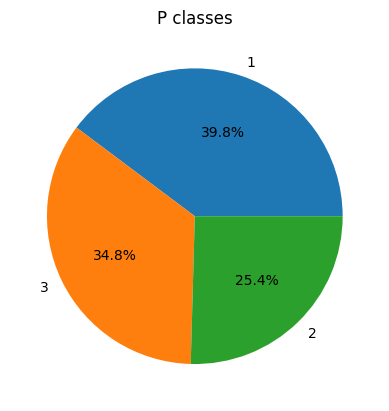

In [17]:
pclass = df[df['Survived']==1]['Pclass'].value_counts()

plt.pie(pclass, labels= pclass.index, autopct='%1.1f%%')
plt.title("P classes")
plt.show()

#plt.bar( pclass.index, pclass, color="green")
#plt.title("P classes")

## Genders

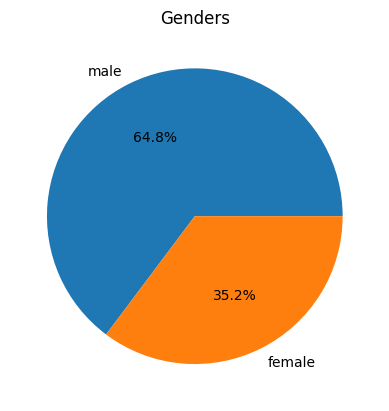

In [22]:
genders = df['Sex'].value_counts()

plt.pie(genders, labels= genders.index, autopct='%1.1f%%')
plt.title("Genders")
plt.show()


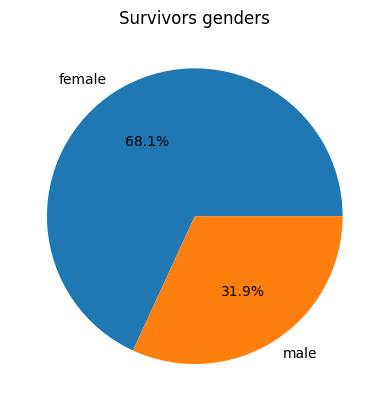

In [23]:
genders = df[df['Survived']==1]['Sex'].value_counts()

plt.pie(genders, labels= genders.index, autopct='%1.1f%%')
plt.title("Survivors genders")
plt.show()


## Age

Q1: 20.125, Q3: 38.0, IQR: 17.875
28.0 - 28.0
----------------
29.69911764705882
28.0
0    24.0
Name: Age, dtype: float64
211.01912474630802
14.526497332334042
0.38910778230082704
0.17827415364210353


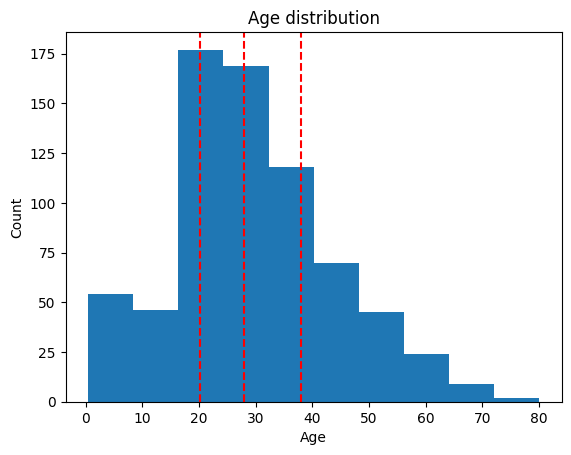

In [24]:
q1 = df['Age'].quantile(0.25)
q3 = df['Age'].quantile(0.75)
iqr = q3 - q1

q2 = df['Age'].quantile(0.5)
age_median = df['Age'].median()

print(f"Q1: {q1}, Q3: {q3}, IQR: {iqr}")
print(f"{age_median} - {q2}")

print("----------------")

print(df['Age'].mean())
print(df['Age'].median())
print(df['Age'].mode())
print(df['Age'].var())
print(df['Age'].std())
print(df['Age'].skew())
print(df['Age'].kurt())

plt.hist(df['Age'])
plt.axvline(q1, color='r', linestyle='--')
plt.axvline(q2, color='r', linestyle='--')
plt.axvline(q3, color='r', linestyle='--')
plt.title("Age distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()


Q1: 19.0, Q3: 36.0, IQR: 17.0
28.0 - 28.0
----------------
28.343689655172415
28.0
0    24.0
Name: Age, dtype: float64
223.5309652320726
14.950951984140428
0.18045773625500755
-0.057601674007564


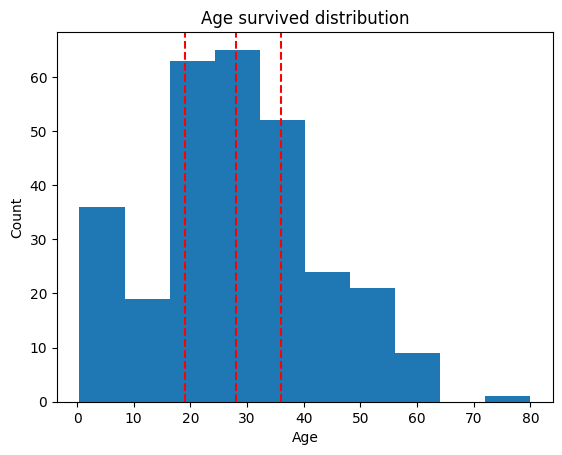

In [26]:
df_srv = df[df['Survived'] == 1]

q1 = df_srv['Age'].quantile(0.25)
q3 = df_srv['Age'].quantile(0.75)
iqr = q3 - q1

q2 = df_srv['Age'].quantile(0.5)
age_median = df['Age'].median()

print(f"Q1: {q1}, Q3: {q3}, IQR: {iqr}")
print(f"{age_median} - {q2}")

print("----------------")

print(df_srv['Age'].mean())
print(df_srv['Age'].median())
print(df_srv['Age'].mode())
print(df_srv['Age'].var())
print(df_srv['Age'].std())
print(df_srv['Age'].skew())
print(df_srv['Age'].kurt())

plt.hist(df_srv['Age'])
plt.axvline(q1, color='r', linestyle='--')
plt.axvline(q2, color='r', linestyle='--')
plt.axvline(q3, color='r', linestyle='--')
plt.title("Age survived distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()


## No. of siblings / spouses aboard the Titanic

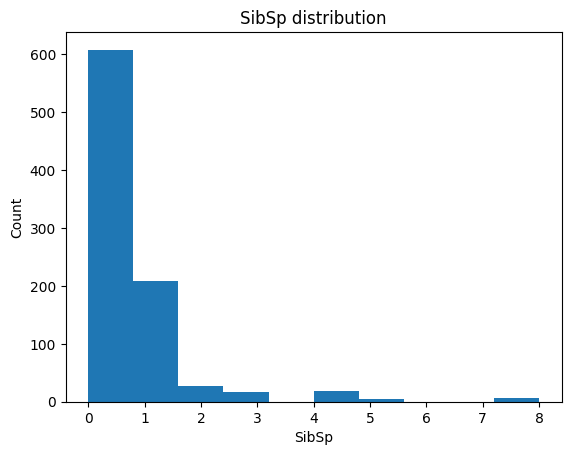

In [27]:
plt.hist(df['SibSp'])
plt.title("SibSp distribution")
plt.xlabel("SibSp")
plt.ylabel("Count")
plt.show()


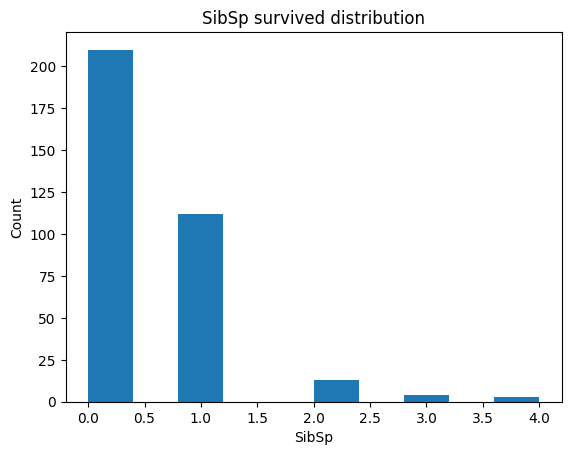

In [28]:
plt.hist(df[df['Survived'] == 1]['SibSp'])
plt.title("SibSp survived distribution")
plt.xlabel("SibSp")
plt.ylabel("Count")
plt.show()

## No. of parents / children aboard the Titanic

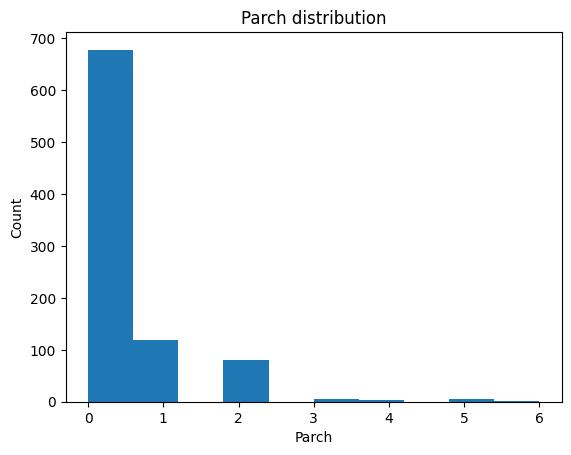

In [29]:
plt.hist(df['Parch'])
plt.title("Parch distribution")
plt.xlabel("Parch")
plt.ylabel("Count")
plt.show()

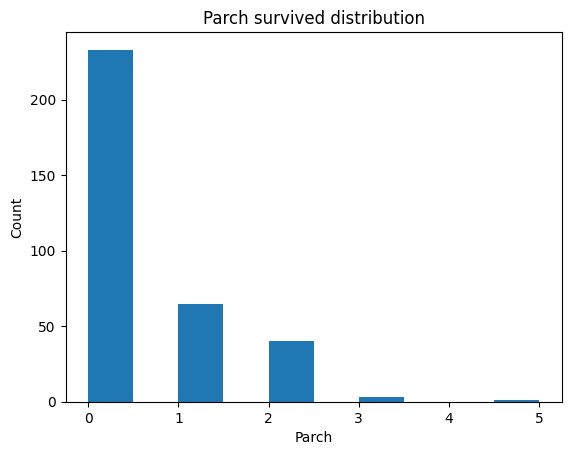

In [30]:
plt.hist(df[df['Survived'] == 1]['Parch'])
plt.title("Parch survived distribution")
plt.xlabel("Parch")
plt.ylabel("Count")
plt.show()

## Fare

Q1: 12.475, Q3: 57.0, IQR: 44.525
26.0 - 26.0
----------------
48.39540760233918
26.0
0    13.0
Name: Fare, dtype: float64
4435.160158368154
66.59699811829475
3.8627793799441936
20.662029528187155


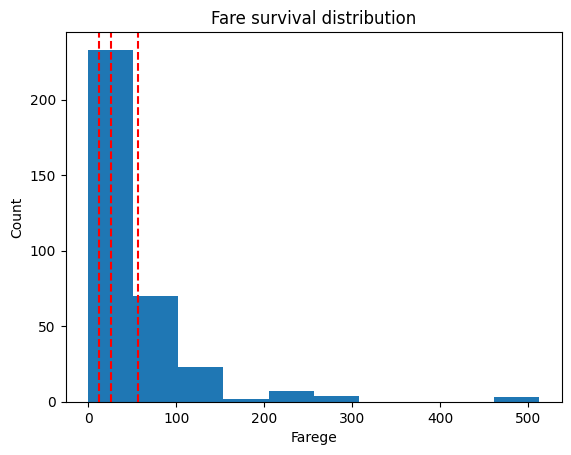

In [31]:
df_sur = df[df['Survived'] == 1]

q1 = df_sur['Fare'].quantile(0.25)
q3 = df_sur['Fare'].quantile(0.75)
iqr = q3 - q1

q2 = df_sur['Fare'].quantile(0.5)
fare_median = df_sur['Fare'].median()
    
print(f"Q1: {q1}, Q3: {q3}, IQR: {iqr}")
print(f"{fare_median} - {q2}")

print("----------------")

print(df_sur['Fare'].mean())
print(df_sur['Fare'].median())
print(df_sur['Fare'].mode())
print(df_sur['Fare'].var())
print(df_sur['Fare'].std())
print(df_sur['Fare'].skew())
print(df_sur['Fare'].kurt())

plt.hist(df_sur['Fare'])
plt.axvline(q1, color='r', linestyle='--')
plt.axvline(q2, color='r', linestyle='--')
plt.axvline(q3, color='r', linestyle='--')
plt.title("Fare survival distribution")
plt.xlabel("Farege")
plt.ylabel("Count")
plt.show()

Q1: 7.8542, Q3: 26.0, IQR: 18.1458
10.5 - 10.5
----------------
22.117886885245902
10.5
0    8.05
Name: Fare, dtype: float64
985.2195092053387
31.38820653056397
4.55314046934547
26.370707228140354


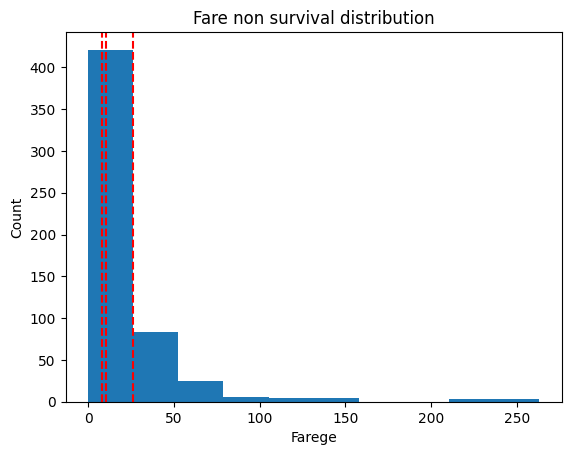

In [32]:
df_nsrv = df[df['Survived'] == 0]

q1 = df_nsrv['Fare'].quantile(0.25)
q3 = df_nsrv['Fare'].quantile(0.75)
iqr = q3 - q1

q2 = df_nsrv['Fare'].quantile(0.5)
fare_median = df_nsrv['Fare'].median()

print(f"Q1: {q1}, Q3: {q3}, IQR: {iqr}")
print(f"{fare_median} - {q2}")

print("----------------")

print(df_nsrv['Fare'].mean())
print(df_nsrv['Fare'].median())
print(df_nsrv['Fare'].mode())
print(df_nsrv['Fare'].var())
print(df_nsrv['Fare'].std())
print(df_nsrv['Fare'].skew())
print(df_nsrv['Fare'].kurt())

plt.hist(df_nsrv['Fare'])
plt.axvline(q1, color='r', linestyle='--')
plt.axvline(q2, color='r', linestyle='--')
plt.axvline(q3, color='r', linestyle='--')
plt.title("Fare non survival distribution")
plt.xlabel("Farege")
plt.ylabel("Count")
plt.show()


# Data preprocessing

## Data cleaning

In [33]:
df.drop(columns=["PassengerId", "Name", "Ticket", "Cabin", "Embarked"], inplace=True)

In [37]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    str    
 3   Age       891 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
dtypes: float64(2), int64(4), str(1)
memory usage: 48.9 KB


In [36]:
df['Age'] = df['Age'].fillna(df['Age'].median())

In [40]:
df['Sex'].unique()

array([1, 0])

In [39]:
df['Sex'] = df['Sex'].map({'female': 0, 'male':1})

## Data preparation for models training